# PHY 480 Final Project
### Vassily Wade
####  5/2/2025

# Solving a 2D Time-Dependent Schrodinger Equation in a Potential Well Using Numerical Methods

## Background and Motivation

The time-dependent Schrodinger equation is a partial differential equation that shows how quantum systems evolve over time. Generally, for most non-trivial potentials, solutions to the time-dependent Schrodinger equation can not be found analytically. I took Quantum Mechanics II this semester so for this project I wanted to investigate the evolution of the observables of a quantum particle confined to a two dimensional potential well with numerical methods. This code will be able to return the probability density of the wave function as well as the time evolution of the expectation values of the system. These results will be able to give information to symmetries of the wave function in different types of potential wells as well as how the physical observables changed based on the potential.

## Methodology

To solve the time-dependent Schrodinger equation there had to be multiple approaches, I needed one numerical method to implement the time evolution of the system and one numerical method to solve the time-dependent Schrodinger. For time evolution of a system the Runge-Kutta 4 method and for the solutions to the equation I decided to use the central finite difference method because it results in lower error than forward and backward difference. I had to make sure I was accounting for working in 2 dimensional space by always doing double integrals and initializing grids instead of lists.

In [1]:
#Setup for the wave function and the potential well that is being used as boundary conditions to solve the Schrodinger equation
import numpy as np
import matplotlib.pyplot as plt

#Initalize the reduced Planck constant as 1, this is a common convention for quantum mechanics because it is purely for units.
hbar = 1
m = 1 # Set the mass of the particle to 1 for simplicity

# Create a grid for the differential equation solvers that are going to be used later
Nx, Ny = 100, 100 
x_min, x_max = -1.0, 1.0 #Working over the interval of [-1, 1] for x and y 
y_min, y_max = -1.0, 1.0
x = np.linspace(x_min, x_max, Nx)
y = np.linspace(y_min, y_max, Ny)
dx = x[1] - x[0] #Need these steps for our numerical solvers
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y, indexing = 'ij') #need this indexing command so that i corresponds to x and j to y so the order must be reversed

# Initalize time evolution for the system
dt = 0.01
Nt = 100

# Random asymmetric well, solver is designed such that for any potential well solutions can be found
def potential_well(X, Y):
    return 10 * (X*2 + 0.8*X*Y + 0.2*Y)

V = potential_well(X, Y) #Initalize the potential energy in the system

# Assume the wave packet is going to be Gaussian so we can follow the form of the gaussian distribution when initializing our wave function
def initial_wavefunction_2d(X, Y, x0= 0.0, y0=0.0, px0 = 0.0, py0=0.0, sigma=0.5):
    return np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)) * \
           np.exp(1j * (px0 * X + py0 * Y) / hbar) #initalizes this wave function with some starting position and momentum, for now both are set to 0  
psi = initial_wavefunction_2d(X, Y)

# The wave function needs to be normalized to recieve any meaningful answers when calculating expectation values
def normalize(psi):
    norm = np.sqrt(np.trapz(np.trapz(np.abs(psi)**2, y), x)) #have to call np trapz twice once to integrate in y then once to integrate in x
    return psi / norm
psi = normalize(psi) #Now we have a normalized wave function to do calculations with

In [2]:
#Setup for the methods to solve the 2D time dependent Schrodinger equation and find meaningful values

#Need to create a function that finds the laplacian, and to find the laplacian need to use a finite differences method
def laplacian_2d(psi, dx, dy):
    d2psi = np.zeros_like(psi, dtype=complex)
    for i in range(1, Nx-1): #have to use these ranges so the loops do not go out of range for the finite differences
        for j in range(1, Ny-1):
            d2x = (psi[i+1, j] - 2 * psi[i, j] + psi[i-1, j]) / dx**2 #finite difference method for a second derivative 
            d2y = (psi[i, j+1] - 2 * psi[i, j] + psi[i, j-1]) / dy**2
            d2psi[i, j] = d2x + d2y #Need to recombine this to still be 2D
    return d2psi

# Hamiltonian of the 2D wave function
def hamiltonian(psi, V, dx, dy):
    kinetic = - (hbar**2 / (2 * m)) * laplacian_2d(psi, dx, dy) #even though hbar and m are one include them in case that changes 
    potential = V * psi
    return kinetic + potential

# Use of the Runge-Kutta 4 solver to find how the wave function evolves over time
def rk4_step(psi, V, dx, dy, dt):
    i_hbar = 1j / hbar #This is the -ihbar that appears in the Schrodinger equation
    k1 = -i_hbar * hamiltonian(psi, V, dx, dy)
    k2 = -i_hbar * hamiltonian(psi + 0.5 * dt * k1, V, dx, dy)
    k3 = -i_hbar * hamiltonian(psi + 0.5 * dt * k2, V, dx, dy)
    k4 = -i_hbar * hamiltonian(psi + dt * k3, V, dx, dy)
    return psi + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

#All expecation value calculations
def expectation_x(psi):
    return np.real(np.trapz(np.trapz(np.conj(psi) * X * psi, y), x)) #even for expectation value of only 1D still need to integrate over the whole space

def expectation_y(psi):
    return np.real(np.trapz(np.trapz(np.conj(psi) * Y * psi, y), x))

def expectation_px(psi):
    dpsi_dx = np.zeros_like(psi, dtype=complex) #Need to include this dtype argument or else type errors will arise from the 1j used to initalize the wave function
    dpsi_dx[1:-1, :] = (psi[2:, :] - psi[:-2, :]) / (2 * dx) #Another use of central finite difference, the indexing is slicing x only because this is the x momentum calculation
    return np.real(np.trapz(np.trapz(np.conj(psi) * (-1j * hbar * dpsi_dx), y), x))

def expectation_py(psi):
    dpsi_dy = np.zeros_like(psi, dtype=complex) #Need to include this dtype argument or else type errors will arise from the 1j used to initalize the wave function
    dpsi_dy[:, 1:-1] = (psi[:, 2:] - psi[:, :-2]) / (2 * dy)
    return np.real(np.trapz(np.trapz(np.conj(psi) * (-1j * hbar * dpsi_dy), y), x))

def expectation_energy(psi, V, dx, dy):
    H_times_psi = hamiltonian(psi, V, dx, dy)
    integrand = np.conj(psi) * H_times_psi #Need the complex conjugate to calculate the expectation value
    return np.real(np.trapz(np.trapz(integrand, y), x)) #another example of double trapezoid rule use first with y and then with x

## Results

The probability density tended towards the extremities but that is where the potential well would be deepest. In symmetric potentials the expectation value of x and y remained constant to where they were initialized which matches our expectations. Adding an asymmetric term in either x or y caused a steady change in the expectation value over time, which yet again matches what we expect, confirming directional acceleration due to the potential gradient. We can also observe that the expectation values of position and momentum are evolving correctly relative to each other using Ehrenfest's theorem. Energy increased rapidly then plateaued over time. This could be because of the wavefunction acquiring kinetic energy as it was pulled through the potential, but most it is likely that this was caused by an error in the boundary conditions.

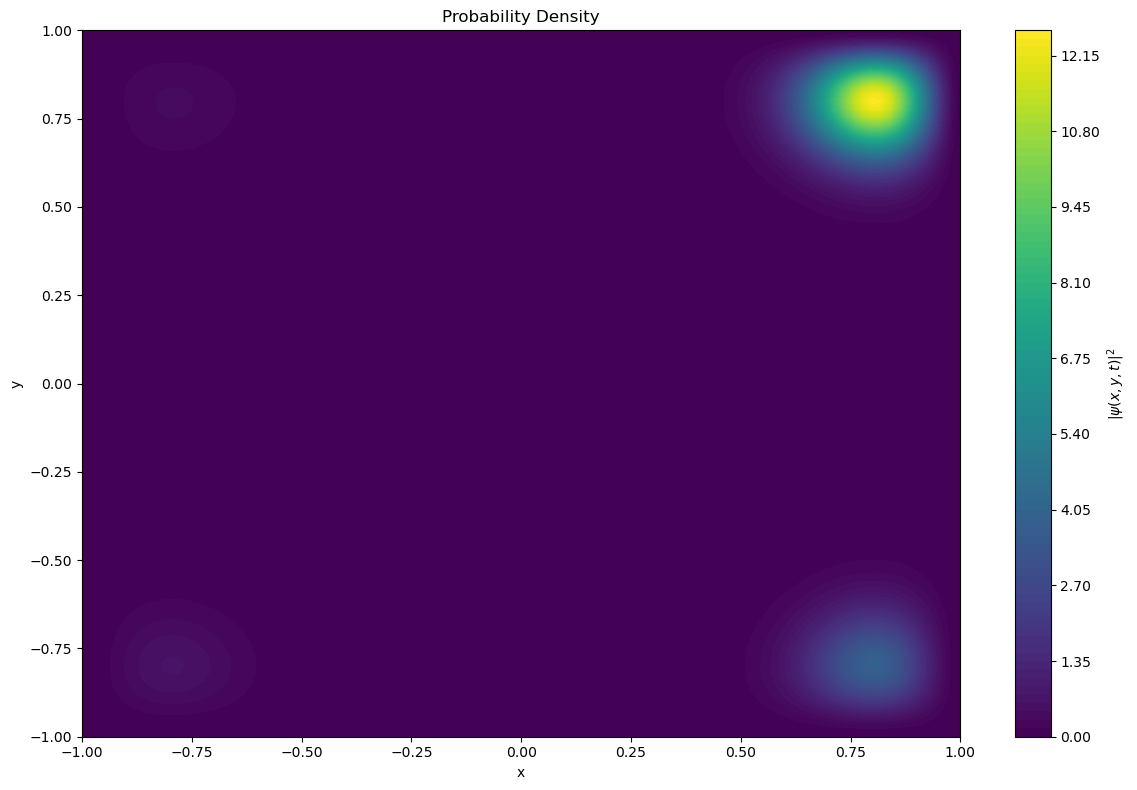

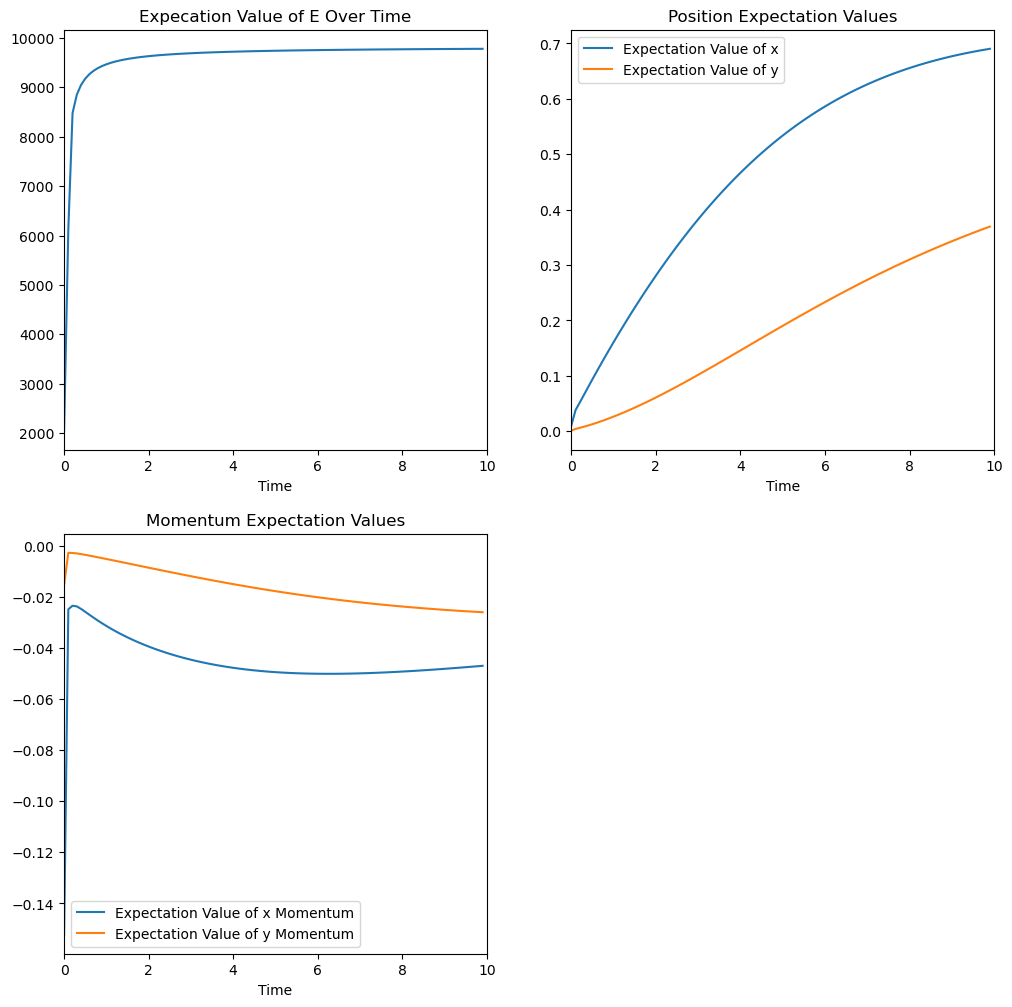

In [3]:
#Time evolution loop
E_expect = []
x_expect = []
y_expect = []
px_expect = []
py_expect = []

for i in range(Nt):
    psi = rk4_step(psi, V, dx, dy, dt) #use the Runge-Kutta method to find the time evolution of each value
    psi = normalize(psi)
    E_expect.append(expectation_energy(psi, V, dx, dy))
    x_expect.append(expectation_x(psi))
    y_expect.append(expectation_y(psi))
    px_expect.append(expectation_px(psi))
    py_expect.append(expectation_py(psi))
    
#Plotting all of the values found    

# Plot final probability density
plt.figure(figsize=(12, 8))
plt.contourf(X, Y, np.abs(psi)**2, levels=100, cmap='viridis') #Contour plots make more sense to visualize any sort of density distribution so for a probability density it is the more logical option for visualization
plt.colorbar(label=r'$|\psi(x,y,t)|^2$') #learned how to include special symbols with python for plots
plt.title("Probability Density")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Plot all of the calculated values over time
time = np.arange(len(E_expect)) * 10 * dt 

plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.plot(time, E_expect)
plt.title("Expecation Value of E Over Time")
plt.xlabel("Time")
plt.xlim(0, 10)

plt.subplot(2, 2, 2)
plt.plot(time, x_expect, label="Expectation Value of x")
plt.plot(time, y_expect, label="Expectation Value of y")
plt.legend()
plt.title("Position Expectation Values")
plt.xlabel("Time")
plt.xlim(0, 10)

plt.subplot(2, 2, 3)
plt.plot(time, px_expect, label="Expectation Value of x Momentum")
plt.plot(time, py_expect, label="Expectation Value of y Momentum")
plt.legend()
plt.title("Momentum Expectation Values")
plt.xlabel("Time")
plt.xlim(0, 10)

plt.show()


## Discussion and Conclusion

From the results we see the greatest affect on the values of the wave function is the symmetry of the potential, the actual behavior of all the observable values depends on symmetries. I also learned the vital importance of the central finite differences method, it is an easy to implement algorithm and it can solve even complicated derivatives with low computational time and error. There were a lot of obstacles with this task, one that I have yet to solve is the problem with the energy at t < 1, the expecation value of the energy rapidly increases then behaves more normally. This could be correct, but it is most likely errors with the boundary conditions of the function and something that I would like to further investigate and fix in the future. I also frequently encountered obstacles with dimensional errors, this was a good experience for me to practice coding with non-1D objects, but there were frequently errors with integration over the whole space or not using the proper dimensions for the central finite differences. Next time I would want to initially choose a simpler potential so that I could compare it to known and accepted values to ensure my method was working correctly. I would also want to implement the possiblity of a multiple well system in which the particle could tunnel as well as making it so the boundaries are not hard cut offs and absorb energy which would model a more realistic system.

### References

* https://hplgit.github.io/fdm-book/doc/pub/book/sphinx/._book008.html
* Had ChatGPT run over my code to ensure no syntax errors, misspellings of variable names, or incorrect usage of certain commands
* Some setup content and methods taken from PHY 415